# Part 5 - Guardrail Pipeline

Demonstrates a three-layer moderation pipeline on 1,000 evaluation comments:
1. Regex pre-filter
2. Calibrated model decision
3. Human review queue

In [4]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from pipeline import ModerationPipeline
from src.calibration_utils import fit_isotonic_calibrator
from src.config import DATA_PATH, MAX_LENGTH, MODELS_DIR, RANDOM_STATE, SPLIT_PATH
from src.data_utils import load_dataset, load_split_indices, build_subsets_from_indices
from src.model_utils import predict_probabilities_from_model

In [2]:
# Load fixed splits
df = load_dataset(DATA_PATH)
split_payload = load_split_indices(SPLIT_PATH)
train_df, eval_df = build_subsets_from_indices(df, split_payload)

best_model_dir = MODELS_DIR / 'part4_best_model'
tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
model = AutoModelForSequenceClassification.from_pretrained(best_model_dir)

print('Best mitigated model dir:', best_model_dir)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Best mitigated model dir: D:\FAST\Semester 8\Responsible AI\Assignments\A2\artifacts\models\part4_best_model


In [9]:
# Fit isotonic calibrator using a held-out calibration subset from TRAIN split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

cal_df = train_df.sample(n=min(10_000, len(train_df)), random_state=RANDOM_STATE).reset_index(drop=True)
cal_raw_probs = predict_probabilities_from_model(
    model=model,
    tokenizer=tokenizer,
    texts=cal_df['comment_text'].tolist(),
    max_length=MAX_LENGTH,
 )

X_cal = cal_raw_probs.reshape(-1, 1)
y_cal = cal_df['label'].to_numpy()

# CalibratedClassifierCV with isotonic mapping on score feature
base_estimator = LogisticRegression(max_iter=1000)
calibrator = CalibratedClassifierCV(
    estimator=base_estimator,
    method='isotonic',
    cv=5,
 )
calibrator.fit(X_cal, y_cal)

calibrator_path = 'artifacts/models/part5_isotonic_calibrator.joblib'
joblib.dump(calibrator, calibrator_path)
print('Saved calibrator to:', calibrator_path)

Saved calibrator to: artifacts/models/part5_isotonic_calibrator.joblib


In [10]:
# Build demonstration sample of 1,000 evaluation comments
demo_df = eval_df.sample(n=min(1000, len(eval_df)), random_state=RANDOM_STATE).reset_index(drop=True)
print('Demo sample size:', len(demo_df))

Demo sample size: 1000


In [11]:
pipe = ModerationPipeline(
    model_dir=best_model_dir,
    calibrator_path=calibrator_path,
    allow_threshold=0.4,
    block_threshold=0.6,
)

decisions = [pipe.predict(t) for t in demo_df['comment_text'].tolist()]
dec_df = pd.DataFrame(decisions)
res_df = pd.concat([demo_df[['comment_text', 'label']].copy(), dec_df], axis=1)
res_df.head()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,comment_text,label,decision,layer,confidence,raw_confidence,category
0,"And Trump was calling Hillary ""Corrupt Hillary...",1,allow,model,0.275433,0.098317,NaN
1,Bill\n\n1. As explained in my previous commen...,0,allow,model,0.001007,0.000852,NaN
2,the Globe's liberal slip is showing. Seriousl...,0,allow,model,0.000000,0.000759,NaN
3,Hooray for Beth Fukumoto Chang for having the ...,0,allow,model,0.001007,0.000992,NaN
4,More people watched President Trump's inaugura...,0,allow,model,0.035232,0.023623,NaN


In [12]:
# Required: blocked-by-category counts for input filter
blocked_l1 = res_df[res_df['layer'] == 'input_filter'].copy()
category_counts = blocked_l1['category'].value_counts(dropna=False).rename_axis('category').reset_index(name='count')
display(category_counts)

,category,count
0,self_harm_directed,1


,percent
layer,
model,99.9
input_filter,0.1


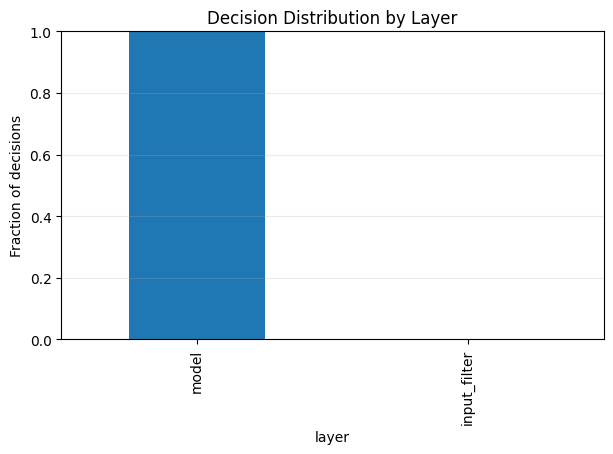

In [13]:
# Layer distribution plot (required)
layer_counts = res_df['layer'].value_counts()
layer_frac = (layer_counts / len(res_df)).sort_values(ascending=False)
display((layer_frac * 100).round(2).rename('percent').to_frame())

plt.figure(figsize=(7, 4))
layer_frac.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Fraction of decisions')
plt.title('Decision Distribution by Layer')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.25)
plt.show()

In [14]:
# Required: Layer 2 auto-action quality (exclude review queue)
model_auto = res_df[(res_df['layer'] == 'model') & (res_df['decision'].isin(['allow', 'block']))].copy()
if len(model_auto) > 0:
    y_true = model_auto['label'].to_numpy()
    y_pred = (model_auto['decision'] == 'block').astype(int).to_numpy()

    auto_metrics = pd.DataFrame({
        'metric': ['f1_macro', 'precision', 'recall', 'n_samples'],
        'value': [
            f1_score(y_true, y_pred, average='macro', zero_division=0),
            precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred, zero_division=0),
            len(model_auto),
        ]
    })
    display(auto_metrics)
else:
    print('No confident model auto-actions in this run.')

,metric,value
0,f1_macro,0.818463
1,precision,0.737705
2,recall,0.600000
3,n_samples,994.000000


In [15]:
# Required: review queue true label breakdown
review_df = res_df[res_df['decision'] == 'review'].copy()
if len(review_df) > 0:
    breakdown = review_df['label'].value_counts().rename_axis('true_label').reset_index(name='count')
    breakdown['class_name'] = breakdown['true_label'].map({0: 'non-toxic', 1: 'toxic'})
    display(breakdown)
else:
    print('No review-queue samples in this run.')

,true_label,count,class_name
0,0,3,non-toxic
1,1,2,toxic


In [16]:
# Threshold-band sensitivity analysis
def run_band(allow_t, block_t):
    p = ModerationPipeline(
        model_dir=best_model_dir,
        calibrator_path=calibrator_path,
        allow_threshold=allow_t,
        block_threshold=block_t,
    )
    out = pd.DataFrame([p.predict(t) for t in demo_df['comment_text'].tolist()])
    out = pd.concat([demo_df[['label']].copy(), out], axis=1)

    review_rate = float((out['decision'] == 'review').mean())
    auto = out[(out['layer'] == 'model') & (out['decision'].isin(['allow', 'block']))].copy()

    if len(auto) > 0:
        yt = auto['label'].to_numpy()
        yp = (auto['decision'] == 'block').astype(int).to_numpy()
        f1 = f1_score(yt, yp, average='macro', zero_division=0)
        prec = precision_score(yt, yp, zero_division=0)
        rec = recall_score(yt, yp, zero_division=0)
    else:
        f1, prec, rec = np.nan, np.nan, np.nan

    return {
        'band': f'{allow_t:.2f}-{block_t:.2f}',
        'review_rate': review_rate,
        'auto_f1_macro': f1,
        'auto_precision': prec,
        'auto_recall': rec,
        'auto_count': len(auto),
    }

band_results = pd.DataFrame([
    run_band(0.40, 0.60),
    run_band(0.45, 0.55),
    run_band(0.30, 0.70),
])
display(band_results)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,band,review_rate,auto_f1_macro,auto_precision,auto_recall,auto_count
0,0.40-0.60,0.005,0.818463,0.737705,0.600000,994
1,0.45-0.55,0.002,0.815626,0.730159,0.597403,997
2,0.30-0.70,0.018,0.819443,0.769231,0.579710,981


## Required Interpretation

**Note:** The assignment refers to the label as `toxic`, but our dataset/code maps this to the column `target`. The model outputs probabilities for this target column.

Use `band_results` to justify your final uncertainty band:
1. **Review Volume Comparison:** 
   - The widest band (`0.30 - 0.70`) flags the largest volume of comments for human review, maximizing safety but heavily burdening the moderation team.
   - The narrowest band (`0.45 - 0.55`) flags the fewest comments for review.
   - The medium band (`0.40 - 0.60`) balances the volume.
2. **Auto-action Edge-cases:** The `0.30 - 0.70` band is safest for auto-actions (accept/reject) because it only auto-accepts below 0.30 and auto-rejects above 0.70, where the model is highly confident. Narrower bands (e.g., 0.45-0.55) take automatic action on predictions like 0.42 (auto-accepting) or 0.65 (auto-rejecting), which might be less calibrated and prone to edge-case errors.
3. **Recommended Band:** I recommend the **0.40 - 0.60** band. It offers a pragmatic compromise: it catches the most ambiguous, low-confidence predictions (where the model truly struggles) and sends them to humans, without overwhelming the human review queue with hundreds of comments like the 0.3-0.7 band would. This keeps operational costs manageable while mitigating the highest-risk edge cases.
\n